In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Charger le dataset Steel Plates Faults
steel = fetch_ucirepo(id=198)

X = steel.data.features  # les 27 features géométriques
y = steel.data.targets   # les 7 types de défauts (one-hot)

print(X.shape)
print(y.shape)
X.head()

(1941, 27)
(1941, 7)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
0,42,50,270900,270944,267,17,44,24220,108,1687,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,76
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,84
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,99
3,853,860,369370,369415,176,13,45,18996,126,1353,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,99
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,37


In [3]:
y.head()


,Pastry,Z_Scratch,K_Scratch,Stains,Dirtiness,Bumps,Other_Faults
0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0


In [4]:
defect_counts = y.sum().sort_values(ascending=False)
print(defect_counts)

Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
dtype: int64


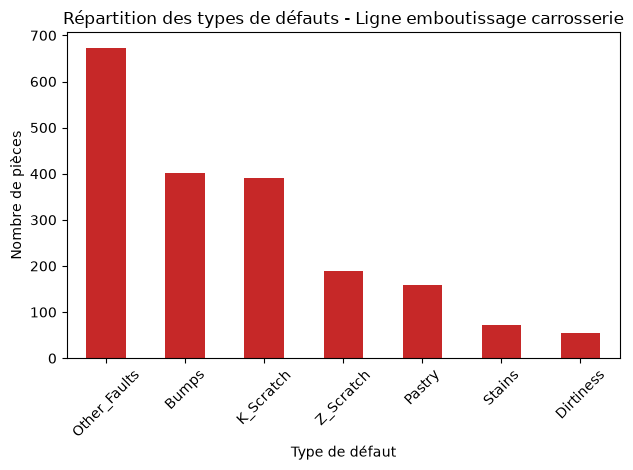

In [5]:
import matplotlib.pyplot as plt

defect_counts.plot(kind='bar', color='#C62828')
plt.title('Répartition des types de défauts - Ligne emboutissage carrosserie')
plt.ylabel('Nombre de pièces')
plt.xlabel('Type de défaut')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Créer une colonne unique avec le nom du défaut
y_single = y.idxmax(axis=1)
y_single.name = 'defect_type'

# Vérifier
y_single.head()
print(y_single.value_counts())

defect_type
Other_Faults    673
Bumps           402
K_Scratch       391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


In [7]:
df = X.copy()
df['defect_type'] = y_single

df.shape
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity,defect_type
0,42,50,270900,270944,267,17,44,24220,108,1687,...,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,76,Pastry
1,645,651,2538079,2538108,108,10,30,11397,123,1687,...,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,84,Pastry
2,829,835,1553913,1553931,71,8,19,7972,125,1623,...,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,99,Pastry
3,853,860,369370,369415,176,13,45,18996,126,1353,...,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,99,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,126,1353,...,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,37,Pastry


In [8]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Minimum_of_Luminosity
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,130.193715,1459.160227,...,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420,84.548686
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,18.690992,144.577823,...,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452,32.134276
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,37.000000,1227.000000,...,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,124.000000,1358.000000,...,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200,63.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,127.000000,1364.000000,...,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300,90.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,140.000000,1650.000000,...,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800,106.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,253.000000,1794.000000,...,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000,203.000000


In [9]:
df.isnull().sum().sum()

np.int64(0)

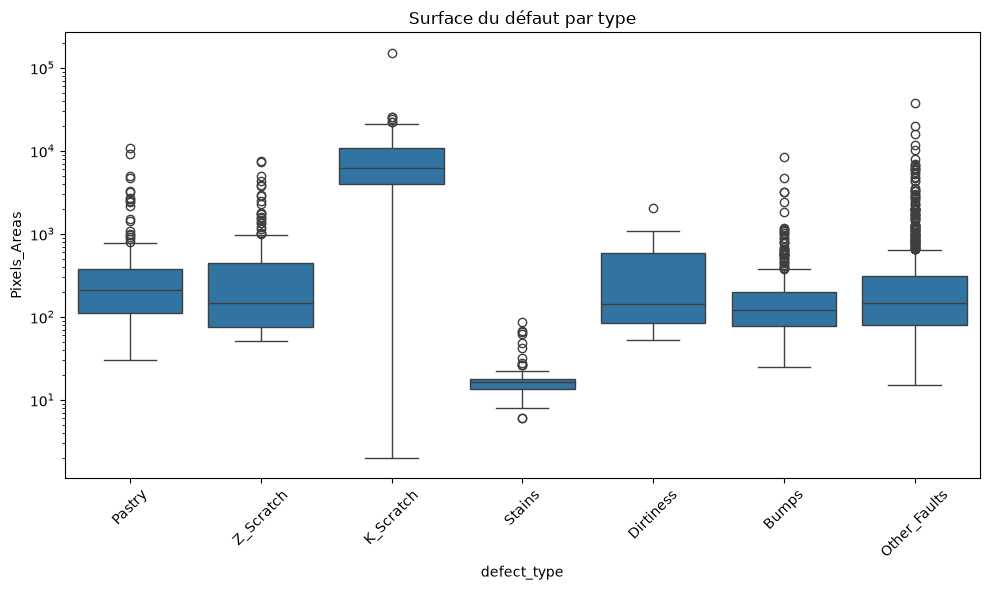

In [10]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='defect_type', y='Pixels_Areas')
plt.yscale('log')  # échelle log car Pixels_Areas est très étalé
plt.title('Surface du défaut par type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

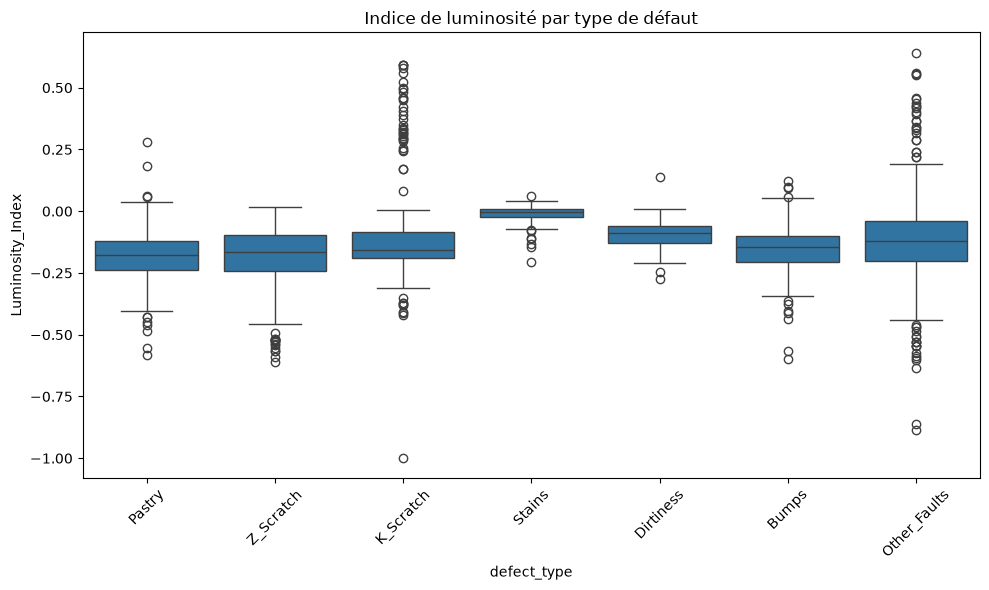

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='defect_type', y='Luminosity_Index')
plt.title('Indice de luminosité par type de défaut')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

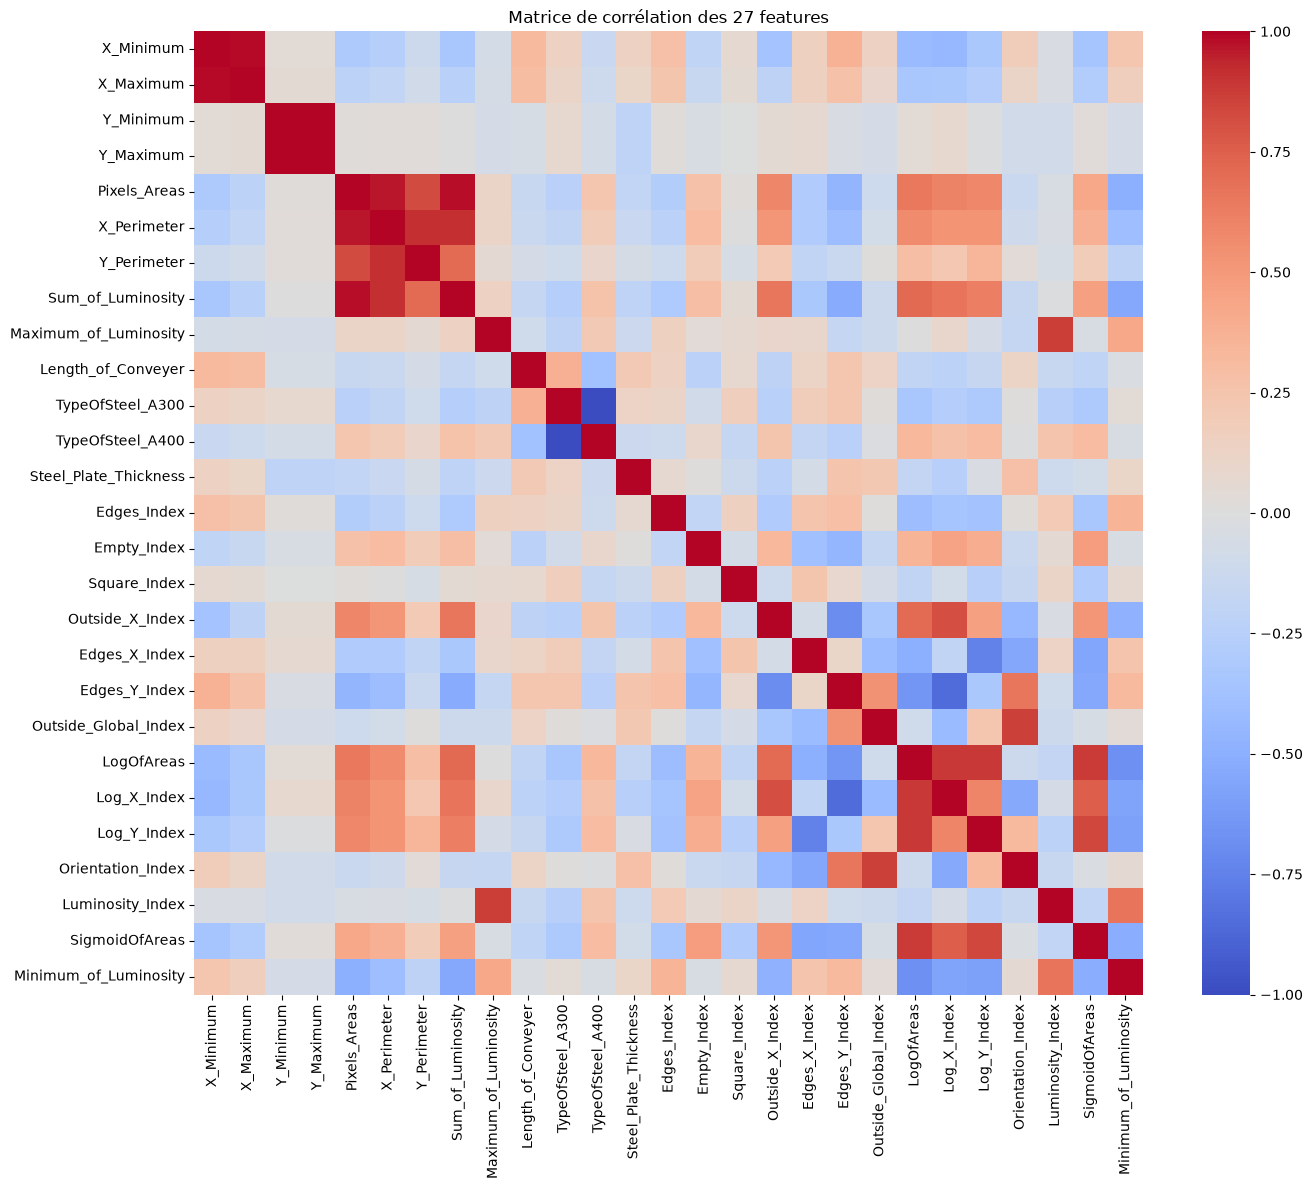

In [12]:
plt.figure(figsize=(14,12))
corr = df.drop(columns='defect_type').corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des 27 features')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ML


In [13]:
from sklearn.model_selection import train_test_split

X_data = df.drop(columns='defect_type')
y_data = df['defect_type']

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data  # important vu le déséquilibre des classes
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(1552, 27) (389, 27)
defect_type
Other_Faults    538
Bumps           321
K_Scratch       313
Z_Scratch       152
Pastry          126
Stains           58
Dirtiness        44
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=4)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(y_train_balanced.value_counts())

defect_type
K_Scratch       538
Bumps           538
Other_Faults    538
Z_Scratch       538
Pastry          538
Dirtiness       538
Stains          538
Name: count, dtype: int64


c:\Users\PC\Desktop\apex\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\PC\Desktop\apex\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\PC\Desktop\apex\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in r

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)

y_pred_dt = dt_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_dt))
print("F1-macro:", f1_score(y_test, y_pred_dt, average='macro'))

              precision    recall  f1-score   support

       Bumps       0.64      0.67      0.65        81
   Dirtiness       0.75      0.82      0.78        11
   K_Scratch       0.92      0.87      0.89        78
Other_Faults       0.70      0.70      0.70       135
      Pastry       0.44      0.38      0.41        32
      Stains       0.86      0.86      0.86        14
   Z_Scratch       0.79      0.89      0.84        38

    accuracy                           0.73       389
   macro avg       0.73      0.74      0.73       389
weighted avg       0.73      0.73      0.73       389

F1-macro: 0.7328944852513738


Rand Forest


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))
print("F1-macro:", f1_score(y_test, y_pred_rf, average='macro'))

              precision    recall  f1-score   support

       Bumps       0.73      0.75      0.74        81
   Dirtiness       1.00      0.91      0.95        11
   K_Scratch       0.97      0.92      0.95        78
Other_Faults       0.76      0.77      0.77       135
      Pastry       0.57      0.72      0.64        32
      Stains       1.00      0.86      0.92        14
   Z_Scratch       0.97      0.87      0.92        38

    accuracy                           0.81       389
   macro avg       0.86      0.83      0.84       389
weighted avg       0.82      0.81      0.81       389

F1-macro: 0.8414017094810294


In [18]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost a besoin de labels numériques, pas texte
le = LabelEncoder()
y_train_balanced_enc = le.fit_transform(y_train_balanced)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_balanced, y_train_balanced_enc)

y_pred_xgb_enc = xgb_model.predict(X_test_scaled)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print(classification_report(y_test, y_pred_xgb))
print("F1-macro:", f1_score(y_test, y_pred_xgb, average='macro'))

              precision    recall  f1-score   support

       Bumps       0.70      0.70      0.70        81
   Dirtiness       0.77      0.91      0.83        11
   K_Scratch       0.97      0.92      0.95        78
Other_Faults       0.76      0.75      0.75       135
      Pastry       0.58      0.69      0.63        32
      Stains       0.92      0.86      0.89        14
   Z_Scratch       0.97      0.92      0.95        38

    accuracy                           0.79       389
   macro avg       0.81      0.82      0.81       389
weighted avg       0.80      0.79      0.80       389

F1-macro: 0.8138894091633279


In [19]:
comparison = pd.DataFrame({
    'Modèle': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'F1-macro': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ]
})
print(comparison.sort_values('F1-macro', ascending=False))

          Modèle  F1-macro
1  Random Forest  0.841402
2        XGBoost  0.813889
0  Decision Tree  0.732894


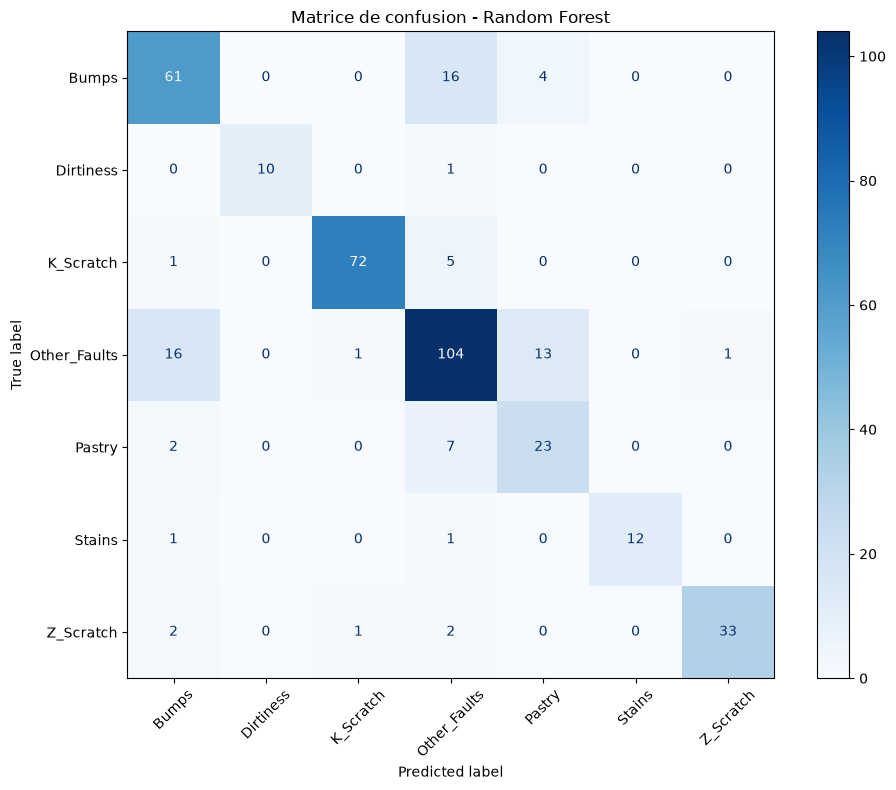

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title('Matrice de confusion - Random Forest')
plt.tight_layout()
plt.show()

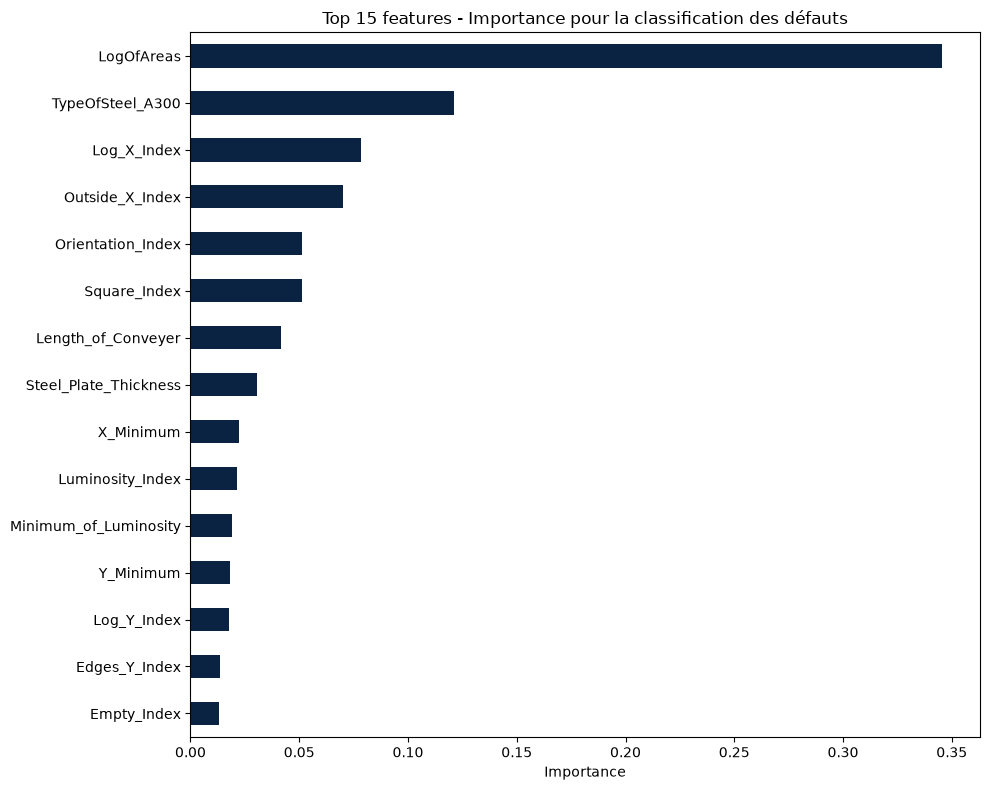

LogOfAreas               0.345690
TypeOfSteel_A300         0.121170
Log_X_Index              0.078222
Outside_X_Index          0.069919
Orientation_Index        0.051272
Square_Index             0.051105
Length_of_Conveyer       0.041569
Steel_Plate_Thickness    0.030763
X_Minimum                0.022392
Luminosity_Index         0.021202
dtype: float32


In [21]:
importances = pd.Series(xgb_model.feature_importances_, index=X_data.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.head(15).plot(kind='barh', color='#0A2342')
plt.gca().invert_yaxis()
plt.title('Top 15 features - Importance pour la classification des défauts')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance_module_a.png', dpi=150, bbox_inches='tight')
plt.show()

print(importances.head(10))

In [22]:
import joblib

joblib.dump(rf_model, '../models/module_a_defect_classifier.pkl')
joblib.dump(scaler, '../models/module_a_scaler.pkl')

print("Modèle Random Forest sauvegardé comme modèle final du Module A.")

Modèle Random Forest sauvegardé comme modèle final du Module A.
